# Seurat label transfer from gut atlas to Xenium  > midplex
- Following 10x vignette here: https://www.10xgenomics.com/analysis-guides/xenium-cell-type-annotation
- Compare midplex to v1 and 5k

In [1]:
library(Seurat)
library(BPCells)
library(SeuratObject)
library(SeuratDisk)
library(tidyverse)
library(jsonlite)
options(future.globals.maxSize = 1e9)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten




In [2]:
#library(SingleCellExperiment)

In [3]:
packageVersion("Seurat")

[1] ‘5.3.0’

In [4]:
# For plotting
library(ggplot2)
library(ggpmisc)
library(scales)
library(cowplot)
library(gridExtra)
library(viridis)
library(hrbrthemes)

Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor



Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




## File info

In [5]:
# Base directory containing rds/seurat outputs
base_dir <- "/home/workspace/projects/drg/data/rds"

# Folder where the .rds files were saved
input_dir <- file.path(base_dir, "seurat")

# Full paths to the Xenium and reference RDS files
xenium_rds_file  <- file.path(input_dir, "adata-xenium.rds")
refdata_rds_file <- file.path(input_dir, "refdata-seq.rds")

# Output folder for downstream label transfer or plots
output_dir <- file.path(base_dir, "seurat")
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

## Load reference reference


In [6]:
ref <- readRDS(refdata_rds_file)

In [7]:
group_counts_df <- as.data.frame(table(ref$cell_label))
colnames(group_counts_df) <- c("group", "count")

print("Annotation counts:")
print(group_counts_df)

[1] "Annotation counts:"
                        group count
1                 Abeta-Field   245
2               Abeta-RA-LTMR   265
3                 Adelta-LTMR   153
4               Angiogenic EC   182
5                      C-LTMR  1415
6                  CGRP-Alpha  1440
7                   CGRP-Beta   134
8               CGRP-Epsilion   848
9                    CGRP-Eta   257
10                 CGRP-Gamma   696
11                 CGRP-Theta   735
12                  CGRP-Zeta   321
13                Cycling SGC   340
14               Fibroblast_1   282
15               Fibroblast_2   207
16               Macrophage_1   405
17               Macrophage_2   146
18 Nonpeptidergic nociceptors  2669
19                   Pericyte   605
20             Proprioceptors   228
21                        SGC 15210
22               Schwann_cell  2699
23                        Sst   757
24                      TrpM8   485
25                    Unknown    81
26     Vascular_endothelial_1  5007
27 

## Load Xenium 

In [8]:
xenium.obj <- readRDS(xenium_rds_file)
DefaultAssay(xenium.obj) <- "Xenium"

In [9]:
xenium.obj

An object of class Seurat 
475 features across 146276 samples within 1 assay 
Active assay: Xenium (475 features, 0 variable features)
 1 layer present: counts
 2 dimensional reductions calculated: latent, umap

## Process xenium

### BP cells

In [10]:
# Path to store on-disk BPCells matrix next to the Xenium RDS
counts_dir <- file.path(input_dir, "xenium_counts_bpcells")

# Overwrite if directory exists
if (dir.exists(counts_dir)) {
  unlink(counts_dir, recursive = TRUE)
}

# Write the counts matrix to disk (BPCells format)
write_matrix_dir(
  mat = xenium.obj[["Xenium"]]$counts,
  dir = counts_dir
)

# Reload matrix in on-disk format and assign back into Seurat object
counts.mat <- open_matrix_dir(dir = counts_dir)
xenium.obj[["Xenium"]]$counts <- counts.mat

rm(counts.mat)

• Consider calling convert_matrix_type if a compressed integer matrix is intended.
This message is displayed once every 8 hours.


475 x 146276 IterableMatrix object with class MatrixDir

Row names: 1500009L16Rik, 6330403K07Rik ... Zfp691
Col names: aaagciof-1-0, aaailodo-1-0 ... oilnmaia-1-7

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /home/workspace/projects/drg/data/rds/seurat/xenium_counts_bpcells

### Xenium QC

[1] 140
[1] 67


Warning message:
“Default search for "data" layer in "Xenium" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


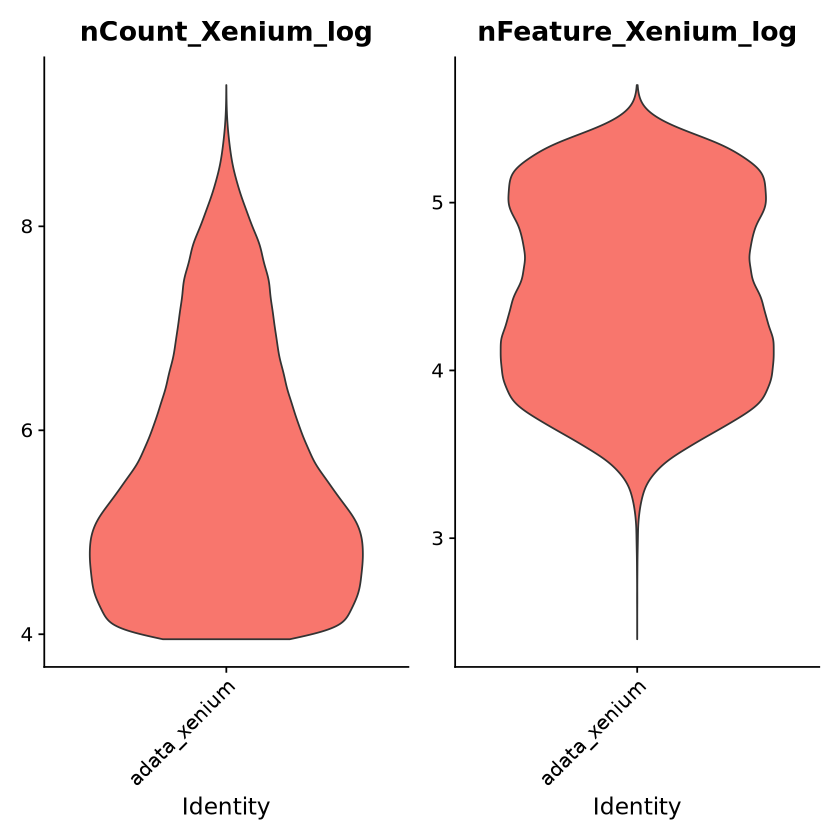

In [11]:
# What is the median tx and gene counts per cell?
print(median(xenium.obj@meta.data$nCount_Xenium))
print(median(xenium.obj@meta.data$nFeature_Xenium))

# Add log1p_nCount_RNA, log1p_nFeatures
xenium.obj@meta.data$nCount_Xenium_log <- log1p(xenium.obj@meta.data$nCount_Xenium)
xenium.obj@meta.data$nFeature_Xenium_log <- log1p(xenium.obj@meta.data$nFeature_Xenium)

# remove cells with < 50 counts (aggressive filter)
xenium.obj <- subset(xenium.obj, subset = nCount_Xenium > 50)

# Violinplots of the transcript and feature counts per cell
VlnPlot(xenium.obj, features = c("nCount_Xenium_log", "nFeature_Xenium_log"), ncol = 2, pt.size = 0, group.by = "orig.ident")

In [12]:
# This function takes in the Xenium and single cell reference Seurat object and returns the per-gene expression means

get_gex_means <- function(xenium_obj, ref_obj){

    xen_means <- data.frame(
        mean_counts = rowMeans(xenium_obj[["Xenium"]]$counts),
        gene = rownames(xenium_obj[["Xenium"]]$counts)
    ) %>%
        arrange(desc(mean_counts)) %>%
        mutate(Rank = 1:n())

    ref_means <- data.frame(
        mean_counts = rowMeans(ref_obj[["RNA"]]$counts),
        gene = rownames(ref_obj[["RNA"]]$counts)
    ) %>%
        arrange(desc(mean_counts)) %>%
        mutate(Rank = 1:n())

    # Merge mean counts per cell,
    merged_means <- merge(xen_means, ref_means, by.x = "gene", by.y = "gene", all.x = TRUE)

    return(merged_means)
}


In [13]:
merged_means <- get_gex_means(xenium.obj, ref)

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_poly_eq()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


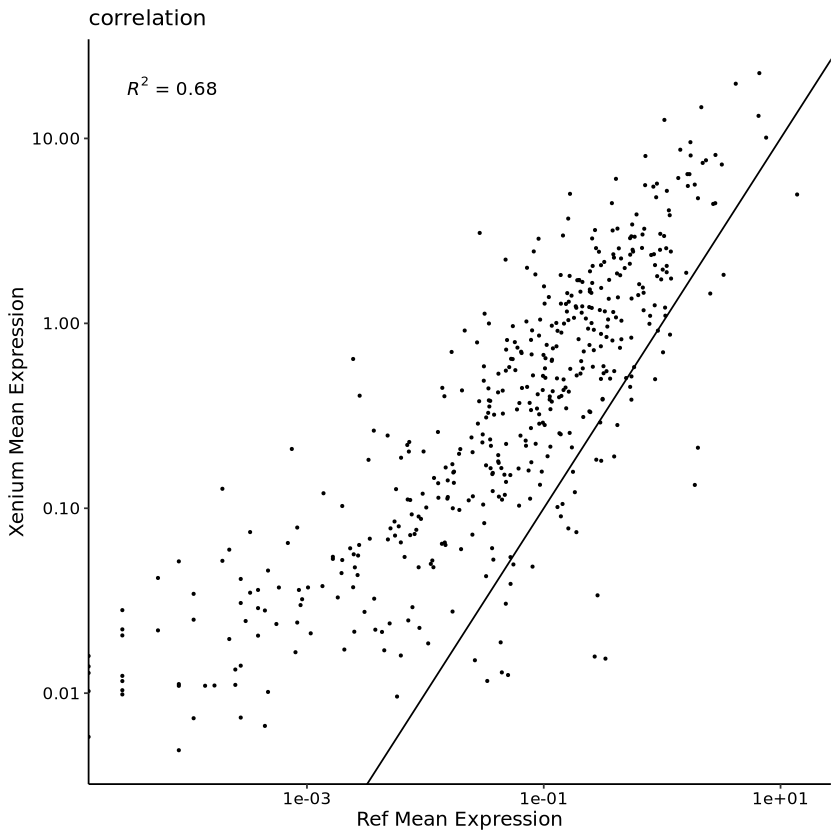

In [14]:
ggplot(merged_means, aes(x=mean_counts.y, y=mean_counts.x)) +
    geom_point(size=0.5) +
    scale_colour_manual(values=c("darkcyan", "coral")) +
    stat_poly_eq() +
    scale_x_log10() +
    scale_y_log10() +
    xlab("Ref Mean Expression") + ylab("Xenium Mean Expression") +
    ggtitle("correlation") +
    theme_classic() +
    theme(axis.text = element_text(color="black", size=10),
          axis.title = element_text(size=12)) +
    geom_abline(slope = 1, intercept = 0) 
    # tune::coord_obs_pred()

### Remove genes detected as noise in Xenium and not expressed in reference 
Removed 12/3; not noise

In [15]:
#n_sd <- 3

#cat('genes before filtering: ', nrow(merged_means), '\n')

# # remove genes with 0 mean counts
# zero_x <- merged_means %>% filter(mean_counts.x == 0) %>% pull(gene)
# zero_y <- merged_means %>% filter(mean_counts.y == 0) %>% pull(gene)
#
# if (length(zero_x) > 0) {
#   cat("removed (mean_counts.x == 0):\n")
#   print(zero_x)
# }
#
# if (length(zero_y) > 0) {
#   cat("removed (mean_counts.y == 0):\n")
#   print(zero_y)
# }
#
# genes_filtered <- merged_means %>% 
#   filter(mean_counts.x != 0) %>% 
#   filter(mean_counts.y != 0) %>%
#   mutate(log_diff = log10(mean_counts.x) - log10(mean_counts.y))
#
# # compute threshold
# mu <- mean(genes_filtered$log_diff, na.rm = TRUE)
# sigma <- sd(genes_filtered$log_diff, na.rm = TRUE)
# log_diff_threshold <- mu + n_sd * sigma
#
# # print genes filtered out due to log_diff threshold
# removed_outliers <- genes_filtered %>% filter(log_diff >= log_diff_threshold)
#
# if (nrow(removed_outliers) > 0) {
#   cat("removed (log_diff >= threshold):\n")
#   print(removed_outliers$gene)
# }
#
# # final filtered genes
# genes_filtered <- genes_filtered %>% filter(log_diff < log_diff_threshold)
#
# cat('genes after filtering: ', nrow(genes_filtered), '\n')

In [16]:
# ggplot(genes_filtered, aes(x=mean_counts.y, y=mean_counts.x)) +
#     geom_point(size=0.5) +
#     scale_colour_manual(values=c("darkcyan", "coral")) +
#     stat_poly_eq() +
#     scale_x_log10() +
#     scale_y_log10() +
#     xlab("Ref Mean Expression") + ylab("Xenium Mean Expression") +
#     ggtitle("correlation") +
#     theme_classic() +
#     theme(axis.text = element_text(color="black", size=10),
#           axis.title = element_text(size=12)) +
#     geom_abline(slope = 1, intercept = 0) 
#     # tune::coord_obs_pred()

In [17]:
#xenium.obj <- subset(xenium.obj, features = genes_filtered$gene)

### Normalization, umap on reference

In [18]:
DefaultAssay(ref) <- "RNA"
ref <- NormalizeData(ref) %>%
                 FindVariableFeatures() %>%
                 ScaleData() %>%
                 RunPCA() %>%
                 RunUMAP(dims=1:15) %>%
                 FindNeighbors(dims=1:15) %>%
                 FindClusters(resolution=0.5)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  Gm42418, Itih5, Ifitm3, Itm2a, Crip1, Ramp2, Col4a2, Txnip, Igfbp7, Tm4sf1 
	   Ly6c1, Cxcl12, Flt1, Klf2, Ly6a, Tcf4, Cdh5, Emcn, Id1, Ly6e 
	   Gsn, Mpz, Ctla2a, Cldn5, Esam, Srgn, Tjp1, Mfsd2a, Abcg2, Adgrl4 
Negative:  15-Sep, Serp2, Pcsk1n, AI413582, Phf24, Cd24a, Syt4, Syt1, Gng3, Fxyd2 
	   Pirt, Mllt11, Dusp26, Trnp1, Meg3, Calcb, Fkbp1b, Tppp3, Prr13, Prph 
	   Cystm1, 9530059O14Rik, Tusc5, Stmn2, Rgs10, Cds2, Parm1, Ldb2, Ret, Ppp1r1c 
PC_ 2 
Positive:  S100a6, Mpz, Mbp, Fabp5, Gsn, Ntrk2, Col1a2, Sncg, Stmn1, Pmp22 
	   Fxyd3, Scd1, Kit, Ogn, Hist1h2bc, S1pr3, S100b, Fgfr1, Tyrp1, Ugt8a 
	   Ncmap, Postn, Crabp1, Cldn19, Pou3f1, Prx, Bcas1, Apoc1, Fdps, Id4 
Negative:  Ly6c1, Flt1, Cxcl12, Igfbp7, Abcg2, Cdh5, Egfl7, Ly6e, Ly6a, Emcn 
	   Tm4sf1, Cav1, Esam, Cd34, Ctla2a, Pecam1, Cldn5, Klf2, Adgrl4, Kitl 
	   Cd93, Abcb1a, Kdr, Plvap, Rbp7, Cyyr1, Fam1

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 36241
Number of edges: 1129240

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9341
Number of communities: 24
Elapsed time: 6 seconds


#### Make named colors for plotting labels consistently 

In [19]:
n_colors <- length(unique(ref$cell_label))
colors_polychrome <- Seurat::DiscretePalette(n = n_colors, palette = "polychrome")
names(colors_polychrome) <-unique(ref$cell_label)

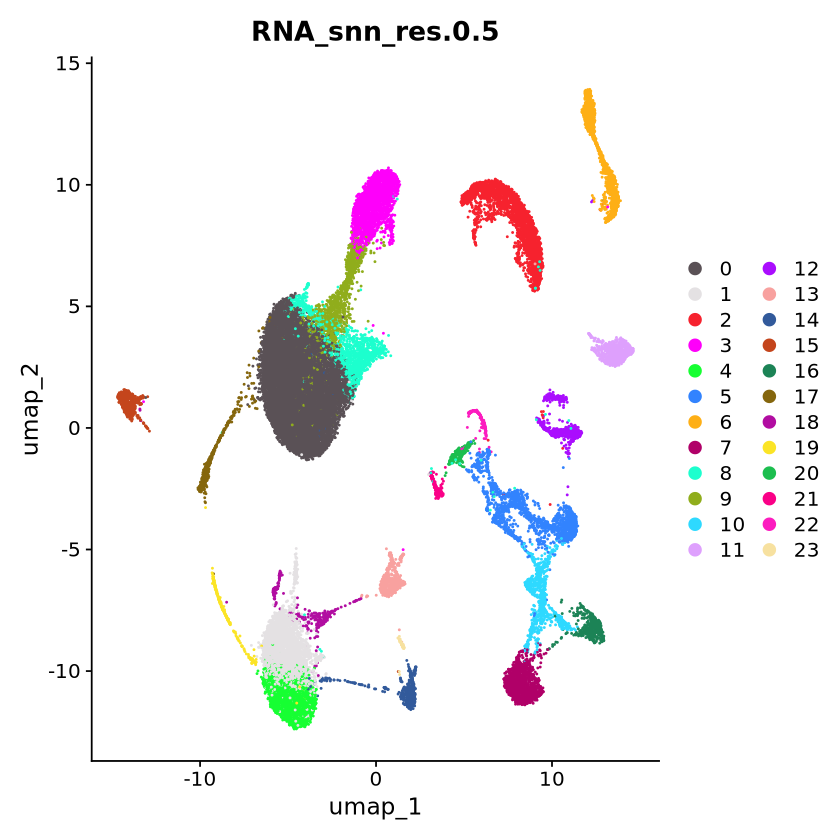

In [20]:
DimPlot(ref, reduction = "umap", cols = "polychrome", group.by = "RNA_snn_res.0.5")

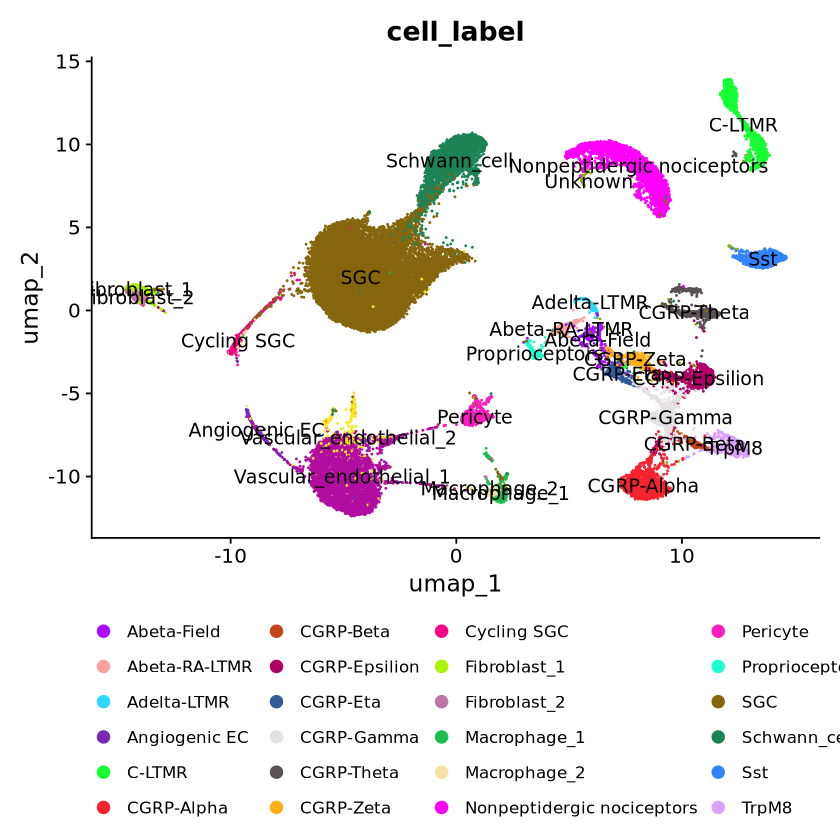

In [21]:
DimPlot(ref, reduction = "umap", 
              cols = colors_polychrome, 
        label=T,
              group.by = "cell_label") +
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

### Normalize, umap on Xenium 

Normalizing layer: counts

Finding variable features for layer counts

Finding variable features for layer counts

PC_ 1 
Positive:  Scn9a, Slc17a6, Nefl, Nefm, Asic2, Arhgdig, Atp1b1, Ret, Syp, Bex1 
	   F2rl2, Ngfr, Scn10a, Scn11a, Resp18, Calcb, 6330403K07Rik, Camk2a, Ache, Vamp1 
	   Nrsn1, Calca, Nefh, Snhg11, Rph3a, Oprm1, Thy1, Ntrk1, Trpv2, Gap43 
Negative:  Prx, Cldn19, Ncmap, Pllp, Ugt8a, Ogn, Mbp, Bcas1, Mlip, Art3 
	   Emid1, Gjc3, Sema3b, Tgfbr2, Nr4a2, Cav1, Col3a1, Sox10, Smoc2, P2rx7 
	   Igfbp7, Pou3f1, Sgk1, Plp1, Fxyd3, Erbb3, Tagln, Cdkn1a, Ctla2a, Ccl11 
PC_ 2 
Positive:  Plp1, Sox10, Art3, Erbb3, Itgb8, Gjc3, Ldhb, Mbp, Sema3b, Sfrp5 
	   Ugt8a, Aspa, Adamts5, Cldn19, Ncmap, Prx, Dhh, Ptprz1, Pllp, Ntrk2 
	   Foxd3, Tafa5, Bcas1, Kcnj10, Fxyd6, P2rx7, Mlip, Endod1, Nr4a2, S1pr3 
Negative:  Ly6a, Ly6c1, Abcb1a, Pecam1, Esam, Cldn5, Slco1a4, Hbb-bt, Cxcl12, Ctla2a 
	   Igfbp7, Vwf, Grrp1, Lef1, Anxa1, H2-Ab1, Rgs5, Ptprc, Myh11, C1qa 
	   S1pr1, Csf1r, Nrp1, Mef2c, 

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 116828
Number of edges: 3434400

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9049
Number of communities: 19
Elapsed time: 50 seconds


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



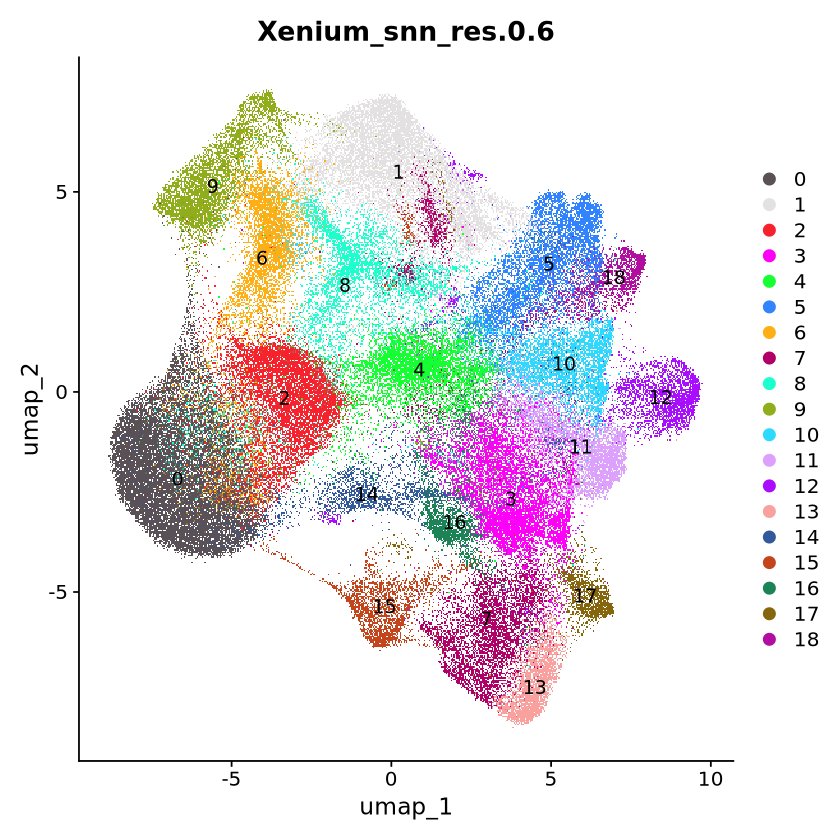

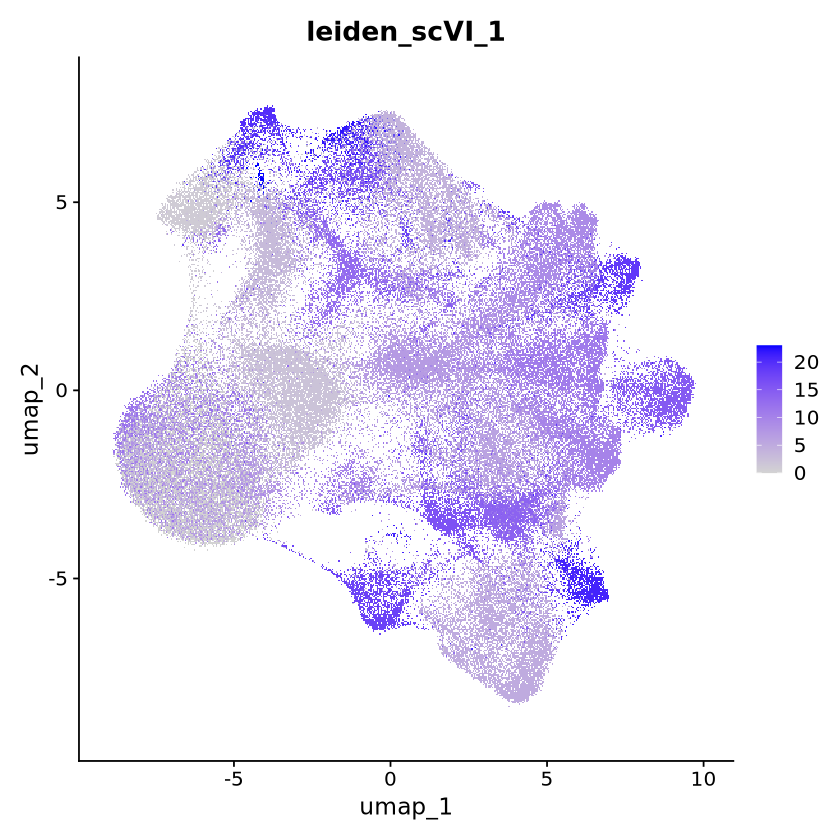

In [22]:
# xenium full dataset (SketchData removed)
DefaultAssay(xenium.obj) <- "Xenium"
xenium.obj <- NormalizeData(xenium.obj)
xenium.obj <- FindVariableFeatures(xenium.obj)

# REMOVE SketchData — using full dataset instead
# xenium.obj <- SketchData(
#     object = xenium.obj,
#     ncells = 100000,
#     method = "LeverageScore",
#     sketched.assay = "sketch"
# )

# keep working in the Xenium assay
DefaultAssay(xenium.obj) <- "Xenium"

# process xenium (full dataset)
xenium.obj <- FindVariableFeatures(xenium.obj) %>%
              ScaleData() %>%
              RunPCA(npcs = 20) %>%
              RunUMAP(dims = 1:16, return.model=TRUE) %>%
              FindNeighbors(reduction = "pca", dims = 1:16) %>%
              FindClusters(resolution = 0.6)

# Plot UMAP
DimPlot(xenium.obj, group.by = "Xenium_snn_res.0.6", 
        cols = "polychrome", label=TRUE, label.size = 4)

markers <- c('leiden_scVI_1')
FeaturePlot(xenium.obj, features = markers)

In [23]:
xenium.obj

An object of class Seurat 
475 features across 116828 samples within 1 assay 
Active assay: Xenium (475 features, 475 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: latent, umap, pca

## Label transfer on sketch xenium

- First subset to common genes: visualize reference umap using these genes only - how well are cell types separated?
- Then run find anchors for label tranfer: Eventually we will want to consolidate some of these labels (combine the labels that do not separate well in above umap), but for now just move forward with current granularity 

[1] 474
[1] "subset ref to common genes and process ref"


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“The following 5 features requested have zero variance; running reduction without them: Jak1, Arhgdig, Il2rb, Lag3, Il13ra1”
PC_ 1 
Positive:  Snhg11, Calcb, Scn9a, Ret, Scn10a, Slc17a6, Scn11a, Asic2, Cd44, Nrsn1 
	   Nmb, F2rl2, Pkib, Tac1, Nptx2, Syp, Rasgrp1, Camk2a, Piezo2, Iqsec2 
	   6330403K07Rik, Ngfr, Bdnf, Gap43, Il6st, Ctxn3, Frmd3, Sox11, Rph3a, Ahi1 
Negative:  Plp1, Fabp7, Ptprz1, Ednrb, Ldhb, Itgb8, Crip1, Sfrp5, Rarres2, Aspa 
	   Art3, Adamts5, Rbp1, Mgst1, Fmo1, Bcan, Sox10, Sema3b, Cald1, Igfbp7 
	   Fxyd3, Gja1, Ogn, Dhh, Gjc3, S100a16, Cxcl12, Foxd3, Entpd1, Erbb3 
PC_ 2 
Positive:  Plp1, Fabp7, Ptprz1, Ednrb, Ldhb, Itgb8, Sfrp5, Aspa, Bcan, Ntrk2 
	   Mbp, Rarres2, Sox10, Tafa5, Fmo1, Sema3b, Art3, Dhh, Kit, Pcdh10 
	   Erbb3, Kcnj10, S1pr3, Gjc3, Fxyd3, Foxd3, Crabp1, Ogn, Slc1a3, Ugt8a 
Negative:  Ly6c1, Cxcl12, Igfbp7, Ly6a, Cldn5, Ctla2a,

[1] "find anchors"


Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 19926 anchors



[1] "label transfer"


Finding integration vectors

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Finding integration vector weights

Predicting cell labels

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



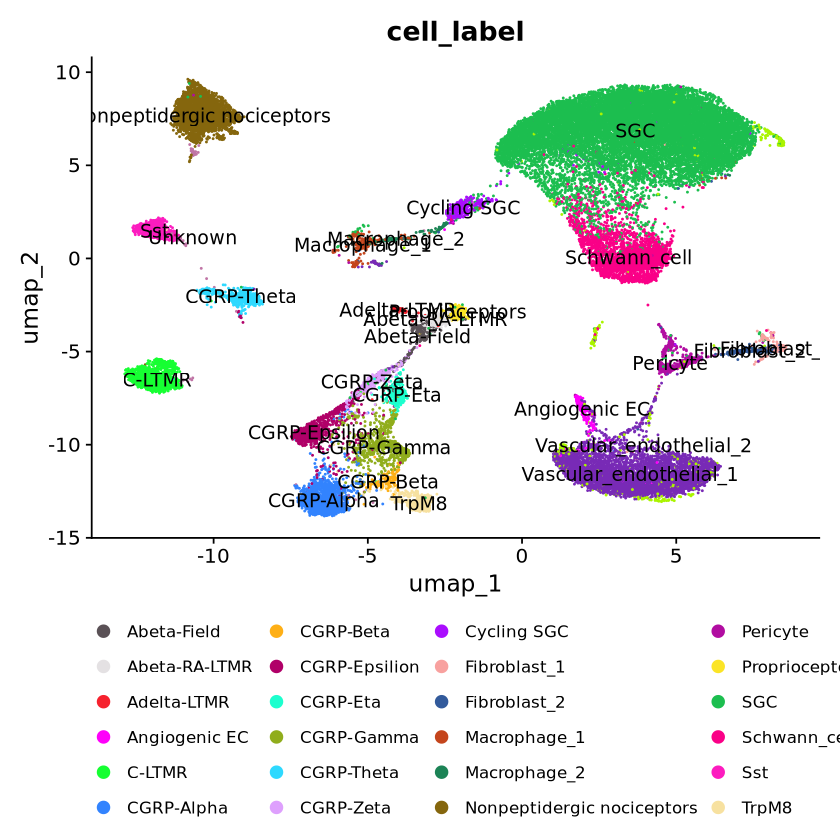

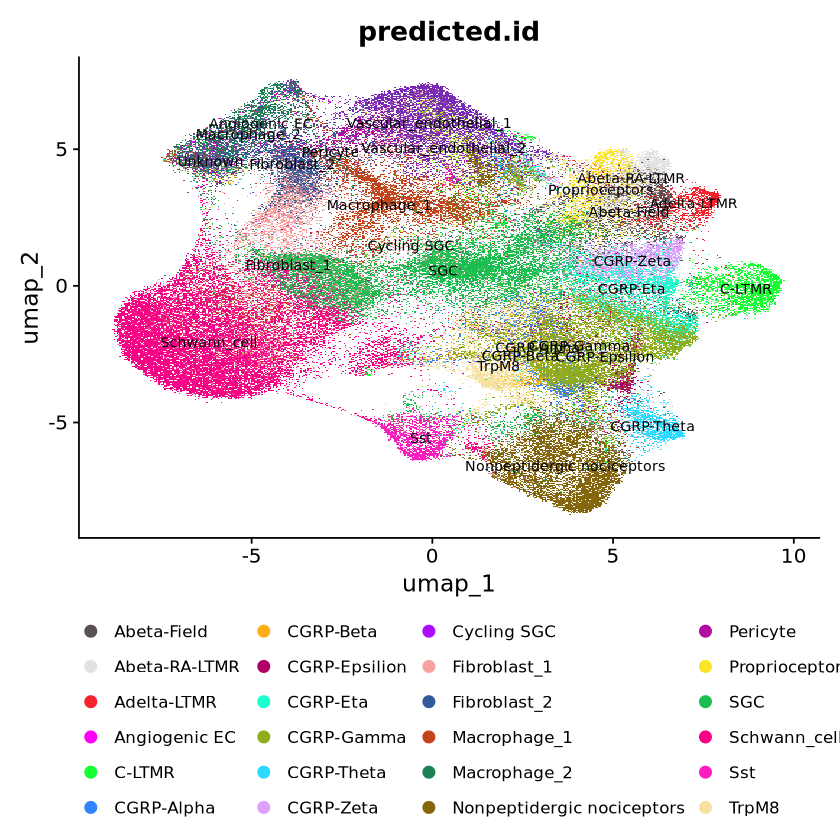

In [24]:
# Get the genes shared between the reference and query datasets
common_genes <- intersect(rownames(xenium.obj), rownames(ref))
print(length(common_genes))

# subset ref to common genes and process
print('subset ref to common genes and process ref')
ref_subset <- CreateSeuratObject(counts = ref[["RNA"]]$counts[common_genes,],
                                 meta = ref@meta.data) %>%
                                NormalizeData() %>%
                                FindVariableFeatures() %>%
                                ScaleData() %>%
                                RunPCA() %>%
                                RunUMAP(dims=1:15) 

# visualize reference subset processed
DimPlot(ref_subset, reduction = "umap", 
              # cols = colors_polychrome, 
        cols = "polychrome", 
        label=T,
              group.by = "cell_label") +
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

# Find anchors
print('find anchors')
ref[["RNA"]]$counts <- as(object = ref[["RNA"]]$counts, Class = "dgCMatrix")

xenium.obj[["Xenium"]]$counts <- as(object = xenium.obj[["Xenium"]]$counts, Class = "dgCMatrix")

anchors_from_ref <- FindTransferAnchors(reference = ref_subset,
                                         query = xenium.obj,
                                         query.assay = "Xenium",
                                         features = common_genes,
                                         dims = 1:20,
                                         reference.reduction = "pca")

# Label transfer
print('label transfer')
label_transfer <- TransferData(anchorset = anchors_from_ref,
                               refdata = ref_subset$cell_label,
                               dims = 1:20)

# add predicted id
xenium.obj <- AddMetaData(object = xenium.obj, metadata = label_transfer, col.name = 'predicted.id')

# visualize
DimPlot(xenium.obj, group.by = c("predicted.id"), 
        cols = "polychrome", 
        label=T, label.size = 3)+
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

In [25]:
# save the xenium object after label transfer 
saveRDS(xenium.obj, file.path(output_dir, 'xenium_processed_labeltransfer.rds'))

## Try co-embedding the xenium and reference 

Then we can visualize the predicted labels in the co-embedding space

In [26]:
# --------------------------
# 1. Standard PCA/UMAP (no integration)
# --------------------------
standard_dim_reduction <- function(obj, seed = 1234){

    DefaultAssay(obj) <- "RNA"
    set.seed(seed)

    obj <- NormalizeData(obj)
    obj <- FindVariableFeatures(obj)
    obj <- ScaleData(obj)
    obj <- RunPCA(obj)

    obj <- FindNeighbors(obj, dims = 1:10, reduction = "pca")
    obj <- FindClusters(obj, resolution = 1, cluster.name = "unintegrated_clusters")

    obj <- RunUMAP(obj, dims = 1:10, reduction = "pca",
                   reduction.name = "umap.unintegrated")

    return(obj)
}


# --------------------------
# 2. CCA integration + UMAP
# --------------------------
integrate_objects <- function(comb_obj,
                              integration_method = CCAIntegration,
                              reduction_name = "integrated.cca",
                              seed = 1234){

    set.seed(seed)

    comb_obj <- IntegrateLayers(
        object = comb_obj,
        method = integration_method,
        orig.reduction = "pca",
        new.reduction = reduction_name,
        verbose = FALSE
    )

    # After integration, rejoin layers
    comb_obj[["RNA"]] <- JoinLayers(comb_obj[["RNA"]])

    comb_obj <- FindNeighbors(comb_obj, reduction = reduction_name, dims = 1:20)
    comb_obj <- FindClusters(comb_obj, resolution = 1)

    comb_obj <- RunUMAP(comb_obj, dims = 1:20,
                        reduction = reduction_name,
                        seed.use = seed)

    return(comb_obj)
}


# --------------------------
# 3. Prepare Xenium + Reference (FULL DATA)
# --------------------------

# Use full Xenium object (NO sketch)
xenium_full <- xenium.obj
DefaultAssay(xenium_full) <- "Xenium"

# Xenium → keep only counts, rename assay → "RNA"
xenium_full_layer <- DietSeurat(
    object = xenium_full,
    assays = "Xenium",
    layers = "counts"
)
xenium_full_layer <- RenameAssays(xenium_full_layer, Xenium = "RNA")

# Reference → keep counts only
ref_layer <- DietSeurat(
    object = ref_subset,
    assays = "RNA",
    layers = "counts"
)

# Tag modality
ref_layer$modality <- "ref"
xenium_full_layer$modality <- "xen"

# Merge full datasets
comb <- merge(ref_layer, y = xenium_full_layer)

cat("Full combined dataset:", paste(dim(comb), collapse = " x "), "\n")


# --------------------------
# 4. Run PCA / CCA / UMAP on FULL dataset
# --------------------------
comb <- standard_dim_reduction(comb)
comb_cca <- integrate_objects(comb, reduction_name = "integrated.cca", seed = 1)

# Save integrated object
saveRDS(comb_cca, file.path(output_dir, "xenium_ref_comb_full.rds"))

Renaming default assay from Xenium to RNA

Warning message:
“Key ‘xenium_’ taken, using ‘rna_’ instead”


Full combined dataset: 475 x 153069 


Normalizing layer: counts.SeuratProject

Normalizing layer: counts.adata_xenium

Finding variable features for layer counts.SeuratProject

Finding variable features for layer counts.adata_xenium

Centering and scaling data matrix

PC_ 1 
Positive:  Scn9a, Slc17a6, Asic2, Syp, Ret, Arhgdig, F2rl2, Bex1, Scn11a, Ngfr 
	   Calcb, Scn10a, Atp1b1, Camk2a, 6330403K07Rik, Resp18, Ache, Snhg11, Nrsn1, Nefl 
	   Vamp1, Rph3a, Oprm1, Tac1, Nefm, Trpv2, Ntrk1, Gap43, Calca, Nptx2 
Negative:  Prx, Cldn19, Ncmap, Pllp, Ogn, Ugt8a, Bcas1, Mlip, Mbp, Emid1 
	   Fxyd3, Art3, Crip1, Plp1, Igfbp7, Cav1, Sema3b, Gjc3, Col3a1, Tgfbr2 
	   Rbp1, Pou3f1, Nr4a2, Ctla2a, Sgk1, Smoc2, Sox10, Tagln, P2rx7, Cdkn1a 
PC_ 2 
Positive:  Ly6a, Ly6c1, Esam, Pecam1, Cldn5, Abcb1a, Slco1a4, Cxcl12, Ctla2a, Igfbp7 
	   Mef2c, Grrp1, Nrp1, Vwf, Hbb-bt, S1pr1, Cd38, Piezo2, Tcf7, Anxa1 
	   Entpd1, Osmr, Cav1, Lef1, Ctxn3, Rgs5, Tgfb2, Myh11, H2-D1, Flt4 
Negative:  Plp1, Sox10, Art3, Erbb3, Itgb8, Gjc3, Mbp, Ldhb, Sema3b,

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 153069
Number of edges: 4384204

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8958
Number of communities: 38
Elapsed time: 87 seconds


10:12:31 UMAP embedding parameters a = 0.9922 b = 1.112

10:12:31 Read 153069 rows and found 10 numeric columns

10:12:31 Using Annoy for neighbor search, n_neighbors = 30

10:12:31 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:12:51 Writing NN index file to temp file /tmp/RtmpR14hND/file66a216d7b2c

10:12:51 Searching Annoy index using 1 thread, search_k = 3000

10:14:09 Annoy recall = 100%

10:14:10 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

10:14:16 Initializing from normalized Laplacian + noise (using RSpectra)

10:14:30 Commencing optimization for 200 epochs, with 6506072 positive edges

10:14:30 Using rng type: pcg

10:16:14 Optimization finished

Warning message:
“The `slot` argument of `SetAssayData()` is depre

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 153069
Number of edges: 4962564

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8960
Number of communities: 33
Elapsed time: 73 seconds


1 singletons identified. 32 final clusters.

10:24:15 UMAP embedding parameters a = 0.9922 b = 1.112

10:24:15 Read 153069 rows and found 20 numeric columns

10:24:15 Using Annoy for neighbor search, n_neighbors = 30

10:24:15 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:24:34 Writing NN index file to temp file /tmp/RtmpR14hND/file66a26475156

10:24:34 Searching Annoy index using 1 thread, search_k = 3000

10:25:50 Annoy recall = 100%

10:25:51 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

10:25:57 Initializing from normalized Laplacian + noise (using RSpectra)

10:26:08 Commencing optimization for 200 epochs, with 7171362 positive edges

10:26:08 Using rng type: pcg

10:28:02 Optimization finished



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



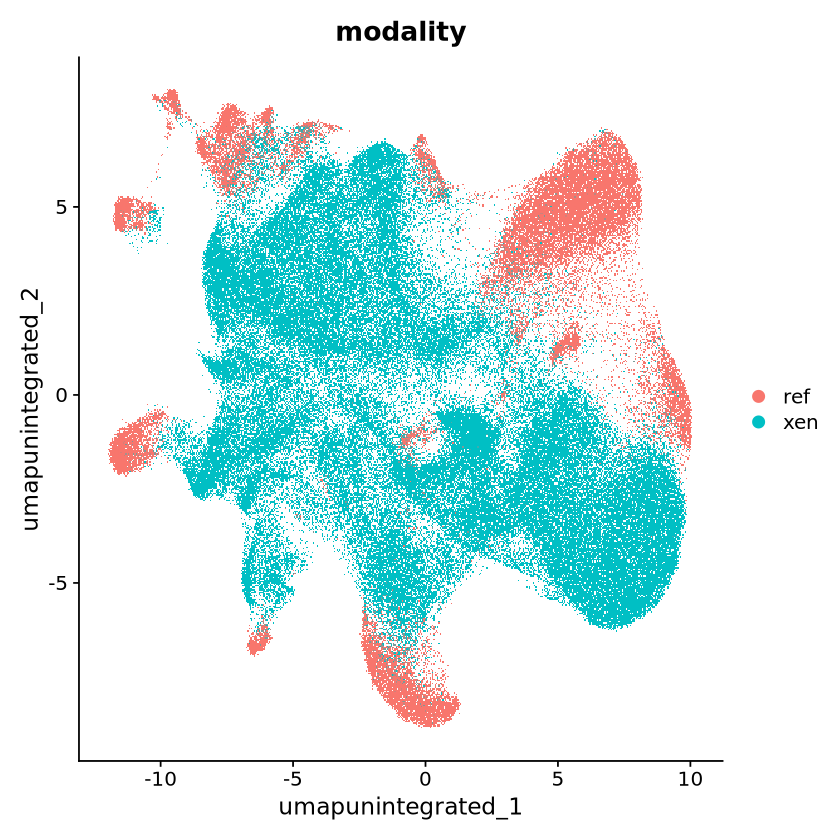

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



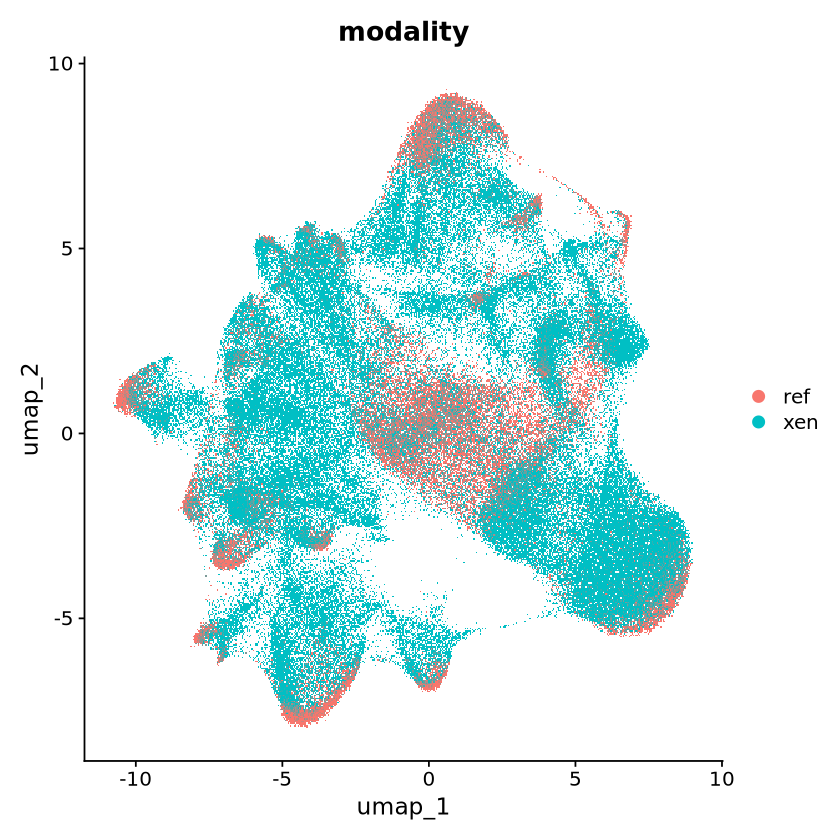

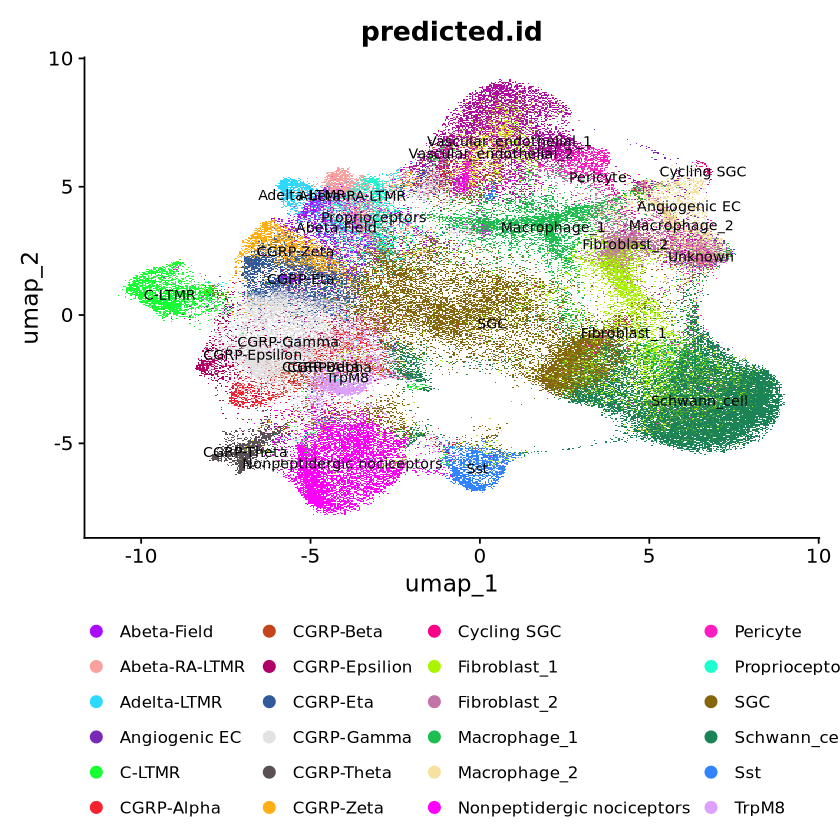

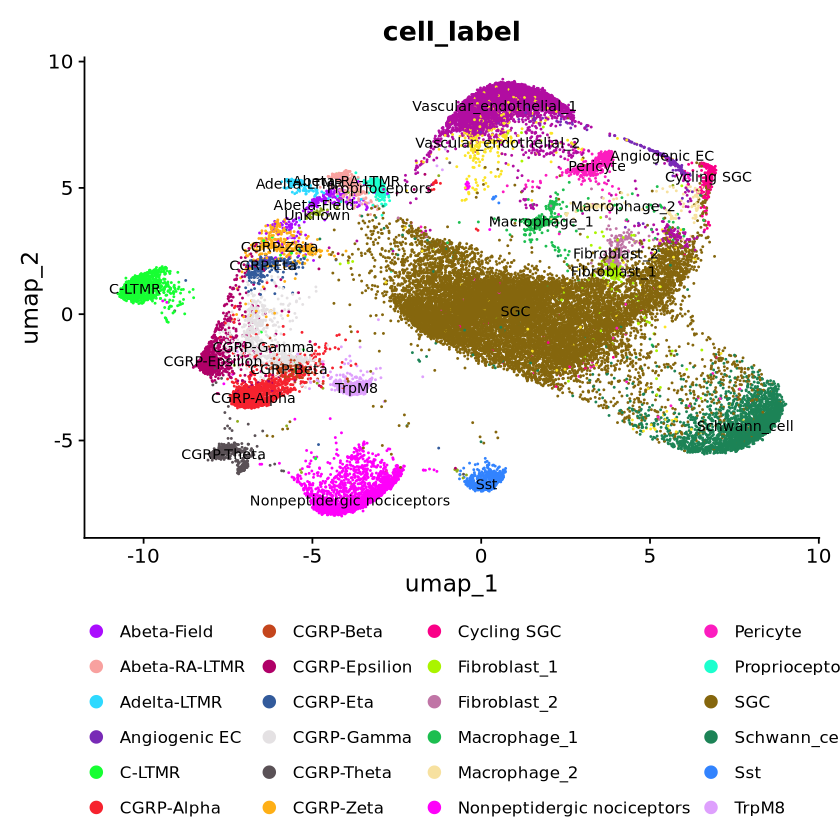

In [27]:
# visualize
DimPlot(comb, reduction = "umap.unintegrated", group.by = "modality")
DimPlot(comb_cca, reduction = "umap", group.by = "modality")

DimPlot(
    subset(comb_cca, modality == "xen"),
    reduction = "umap",
    group.by = "predicted.id",
    label = TRUE,
    label.size = 3,
    cols = colors_polychrome
) +
  theme(
    legend.position = "bottom",
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

DimPlot(
    subset(comb_cca, modality == "ref"),
    reduction = "umap",
    group.by = "cell_label",
    label = TRUE,
    label.size = 3,
    cols = colors_polychrome
) +
  theme(
    legend.position = "bottom",
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

In [28]:
write.csv(label_transfer, file = file.path(output_dir, "20251204_label_transfer_xenium.csv"), row.names = TRUE)

In [29]:
label_transfer

,predicted.id,prediction.score.CGRP.Theta,prediction.score.CGRP.Gamma,prediction.score.CGRP.Alpha,prediction.score.Nonpeptidergic.nociceptors,prediction.score.C.LTMR,prediction.score.Sst,prediction.score.CGRP.Zeta,prediction.score.CGRP.Epsilion,prediction.score.Proprioceptors,⋯,prediction.score.Vascular_endothelial_1,prediction.score.Vascular_endothelial_2,prediction.score.Macrophage_1,prediction.score.Cycling.SGC,prediction.score.Pericyte,prediction.score.Macrophage_2,prediction.score.Fibroblast_2,prediction.score.Angiogenic.EC,prediction.score.Fibroblast_1,prediction.score.max
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
aaagciof-1-0,Abeta-RA-LTMR,0.0000000,0.00000000,0.0000000,0.000000,0.0000000,0,0.00000000,0.000000000,0.02916968,⋯,0,0,0,0,0,0,0,0,0,0.3865936
aaailodo-1-0,CGRP-Eta,0.0000000,0.00000000,0.0000000,0.000000,0.0000000,0,0.00000000,0.000000000,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0.8761256
aaanacfp-1-0,Adelta-LTMR,0.0000000,0.00000000,0.0000000,0.000000,0.0000000,0,0.00000000,0.000000000,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0.9975522
aaaohjeo-1-0,SGC,0.0000000,0.00000000,0.0000000,0.000000,0.0000000,0,0.00000000,0.000000000,0.28081200,⋯,0,0,0,0,0,0,0,0,0,0.5540472
aabfmjal-1-0,Abeta-Field,0.0000000,0.00000000,0.0000000,0.000000,0.0000000,0,0.00000000,0.000000000,0.03082257,⋯,0,0,0,0,0,0,0,0,0,0.7332158
aabgnikc-1-0,SGC,0.0000000,0.00000000,0.0000000,0.000000,0.0000000,0,0.00000000,0.000000000,0.02867814,⋯,0,0,0,0,0,0,0,0,0,0.9452604
aabhichh-1-0,CGRP-Gamma,0.0000000,0.78017421,0.0000000,0.000000,0.0000000,0,0.00000000,0.000000000,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0.7801742
aabilchf-1-0,Adelta-LTMR,0.0000000,0.00000000,0.0000000,0.000000,0.0000000,0,0.00000000,0.000000000,0.00000000,⋯,0,0,0,0,0,0,0,0,0,0.7870336
aabliboc-1-0,SGC,0.0000000,0.00000000,0.0000000,0.000000,0.0000000,0,0.00000000,0.000000000,0.00000000,⋯,0,0,0,0,0,0,0,0,0,1.0000000


In [30]:
dim(label_transfer)

[1] 116828     29

In [31]:
barcodes_of_interest <- c(
  "apeeemip-1-1",
  "bpoikicj-1-1",
  "cbhmmeof-1-1",
  "akcoadof-1-2",
  "bgmdeeeb-1-2",
  "hjjgalia-1-2",
  "hjjkhdhk-1-2",
  "mnhcfodp-1-2",
  "bmjgagok-1-3",
  "ijnggkoc-1-3",
  "llknggjo-1-3",
  "llmfnafp-1-3",
  "llmgffik-1-3"
)
# make prefixes like "apeeemip-1"
prefixes <- sub("-[0-9]+$", "", barcodes_of_interest)

compact_results <- lapply(seq_along(prefixes), function(i) {

  p <- prefixes[i]
  bc <- barcodes_of_interest[i]

  # matches
  hits <- label_transfer[grepl(p, rownames(label_transfer)), "predicted.id", drop = FALSE]

  if (nrow(hits) == 0) {
    return(data.frame(
      barcode = bc,
      prefix = p,
      predicted.id = NA
    ))
  }

  # return first match only (compact)
  data.frame(
    barcode = bc,
    prefix = p,
    predicted.id = hits$predicted.id[1]
  )
})

compact_results <- do.call(rbind, compact_results)
compact_results

barcode,prefix,predicted.id
<chr>,<chr>,<chr>
apeeemip-1-1,apeeemip-1,Vascular_endothelial_1
bpoikicj-1-1,bpoikicj-1,CGRP-Gamma
cbhmmeof-1-1,cbhmmeof-1,CGRP-Gamma
akcoadof-1-2,akcoadof-1,CGRP-Gamma
bgmdeeeb-1-2,bgmdeeeb-1,CGRP-Gamma
hjjgalia-1-2,hjjgalia-1,CGRP-Gamma
hjjkhdhk-1-2,hjjkhdhk-1,CGRP-Eta
mnhcfodp-1-2,mnhcfodp-1,CGRP-Gamma
bmjgagok-1-3,bmjgagok-1,CGRP-Gamma
